# MiniProyecto Deep Learning
## Elaborado por Fabián Calvo Castillo - Florencia Pellegrini

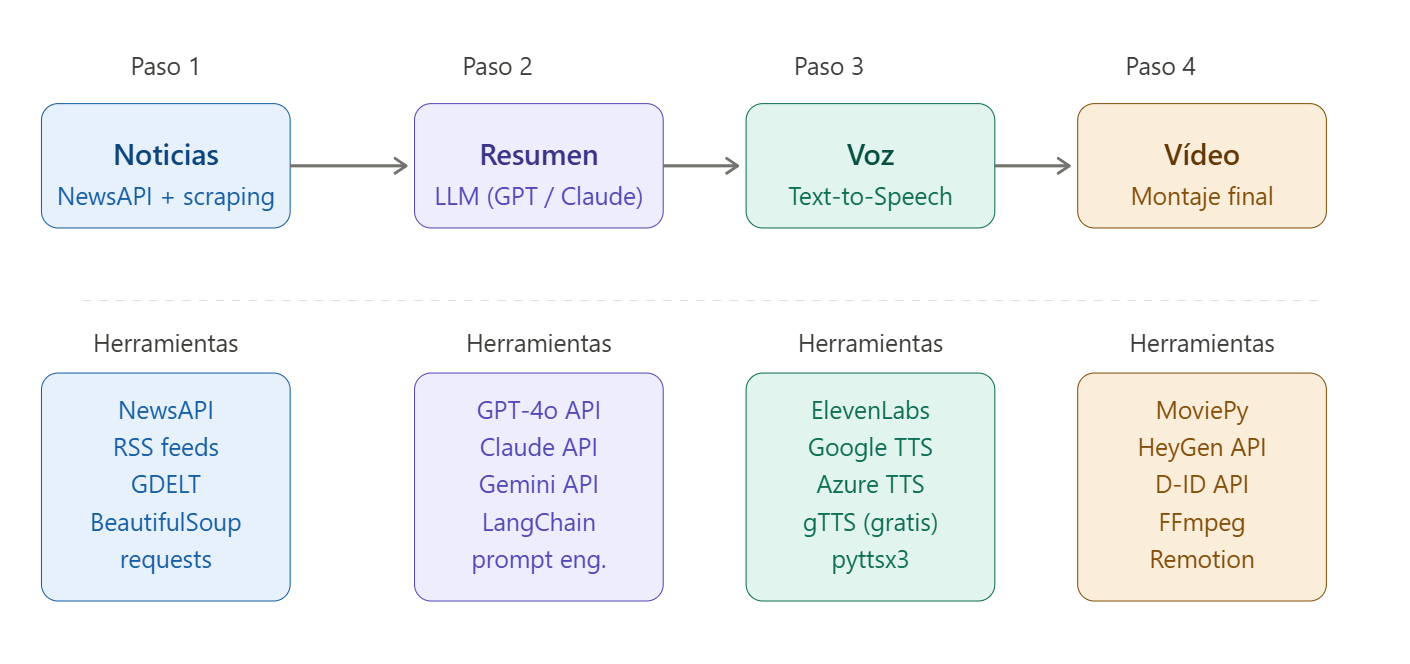

## Paso 1: Obtener noticias

Usamos NewsAPI, que tiene un tier gratuito que permite 100 peticiones/día y devuelve artículos de cientos de medios. Te da título, descripción, URL, fuente y fecha de cada noticia en formato JSON.

Flujo: pedir a NewsAPI noticias sobre un tema/categoría → agrupar las que hablen del mismo evento → quedarnos con el texto relevante de cada una para pasárselo después al LLM.

In [ ]:
from news_fetcher import get_all_news

if __name__ == "__main__":
    articulos = get_all_news(num_per_source=3)

    print("\\nRESUMEN POR FUENTE:")
    fuentes = {}
    for art in articulos:
        fuente = art["fuente"]
        if fuente not in fuentes:
            fuentes[fuente] = {"completos": 0, "resumenes": 0}
        if art["texto_origen"] == "completo":
            fuentes[fuente]["completos"] += 1
        else:
            fuentes[fuente]["resumenes"] += 1

    for fuente, stats in fuentes.items():
        print(f"  {fuente:<15} completos: {stats[\'completos\']}  |  resumen RSS: {stats[\'resumenes\']}")